In [13]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# transformation for the Training (with Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Trasformation for Validation and Test (only resize and normalization, without distortion)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [14]:
dataset_path = 'dataset/Garbage classification'

# two view of the dataset, one for training and one for testing
full_train_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transforms)
full_test_dataset = datasets.ImageFolder(root=dataset_path, transform=test_transforms)

# let's verify that PyTorch is seeing all 6 classes
print(f"Classes found: {full_train_dataset.classes}")

# different dataset groups size
total_size = len(full_train_dataset)
train_size = int(0.7 * total_size)   # 70%
val_size = int(0.15 * total_size)    # 15%
test_size = total_size - train_size - val_size # 15%

print(f"Tot Images: {total_size}")
print(f"Training: {train_size} | Validation: {val_size} | Test: {test_size}")

# we need to create random index to mix photos before dividing them, so we use seed to make the action reproducible
torch.manual_seed(42)
indices = torch.randperm(total_size).tolist()

train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size :]

# we assign the photos to the various groups. we pass "full_test_dataset" to val and test to not have the data augmentation
train_data = Subset(full_train_dataset, train_idx)
val_data = Subset(full_test_dataset, val_idx)
test_data = Subset(full_test_dataset, test_idx)

# create the DataLoader that loads the packets to the GPU
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Data ready")

Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Tot Images: 2527
Training: 1768 | Validation: 379 | Test: 380
Data ready


In [15]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 1. Check if GPU is active
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Define our Custom CNN Architecture from Scratch (Baseline Model)
class TrashNet(nn.Module):
    def __init__(self, num_classes=6):
        super(TrashNet, self).__init__()
        
        # Block 1: Feature Extraction
        # Input channels = 3 (RGB), Output channels = 16
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2: Deeper Feature Extraction
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 3: Final Feature Extraction
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 4: Classification (Fully Connected Layers)
        # Math: 224x224 image divided by 2 three times = 28x28. 64 channels.
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.dropout = nn.Dropout(0.5) # Prevents overfitting
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Pass through Block 1
        x = self.pool1(F.relu(self.conv1(x)))
        # Pass through Block 2
        x = self.pool2(F.relu(self.conv2(x)))
        # Pass through Block 3
        x = self.pool3(F.relu(self.conv3(x)))
        
        # Flatten the tensor for the linear layers
        x = x.view(-1, 64 * 28 * 28)
        
        # Pass through Classification Head
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 3. Instantiate the model and move to GPU
model_custom = TrashNet(num_classes=6)
model_custom = model_custom.to(device)

print("Custom TrashNet architecture built successfully!")

Using device: cpu
Custom TrashNet architecture built successfully!


In [16]:
import copy
import time
from torch.optim import lr_scheduler

# Define the local filename for our Custom Model weights
custom_weights_path = 'baseline_weights.pth'

# Define Loss function
criterion = nn.CrossEntropyLoss()

# We optimize ALL parameters since we built it from scratch (no frozen layers)
optimizer = optim.Adam(model_custom.parameters(), lr=0.001)

# Decay LR by a factor of 0.5 every 5 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# --- THE SMART CHECK ---
if os.path.exists(custom_weights_path):
    print(f"File '{custom_weights_path}' found! Loading the pre-trained Baseline Model...")
    model_custom.load_state_dict(torch.load(custom_weights_path, map_location=device))
    print("Baseline Model loaded successfully! Skipping training loop.")
    skip_training = True
else:
    print(f"File '{custom_weights_path}' NOT found. Starting training from scratch...")
    skip_training = False

# --- TRAINING LOOP (Only runs if we don't have saved weights) ---
if not skip_training:
    epochs = 30 
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model_custom.state_dict())
    start_time = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        print("-" * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model_custom.train()
                dataloader = train_loader
            else:
                model_custom.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model_custom(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
            
            # Step the scheduler AFTER the train phase is complete
            if phase == 'train':
                exp_lr_scheduler.step()

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model_custom.state_dict())

        print()

    time_elapsed = time.time() - start_time
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Accuracy (Baseline): {best_acc:.4f}")

    # Load the best weights
    model_custom.load_state_dict(best_model_wts)
    
    # Save the custom weights to disk
    torch.save(model_custom.state_dict(), custom_weights_path)
    print(f"Baseline Model saved to '{custom_weights_path}'!")

File 'baseline_weights.pth' found! Loading the pre-trained Baseline Model...
Baseline Model loaded successfully! Skipping training loop.


Avvio della valutazione sul Test Set per la Baseline (TrashNet)...

Classi rilevate: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

--- Classification Report (Baseline) ---
              precision    recall  f1-score   support

   cardboard       0.88      0.86      0.87        59
       glass       0.75      0.82      0.79        78
       metal       0.70      0.74      0.72        61
       paper       0.82      0.88      0.85        92
     plastic       0.68      0.59      0.63        66
       trash       0.82      0.58      0.68        24

    accuracy                           0.77       380
   macro avg       0.78      0.75      0.76       380
weighted avg       0.77      0.77      0.77       380



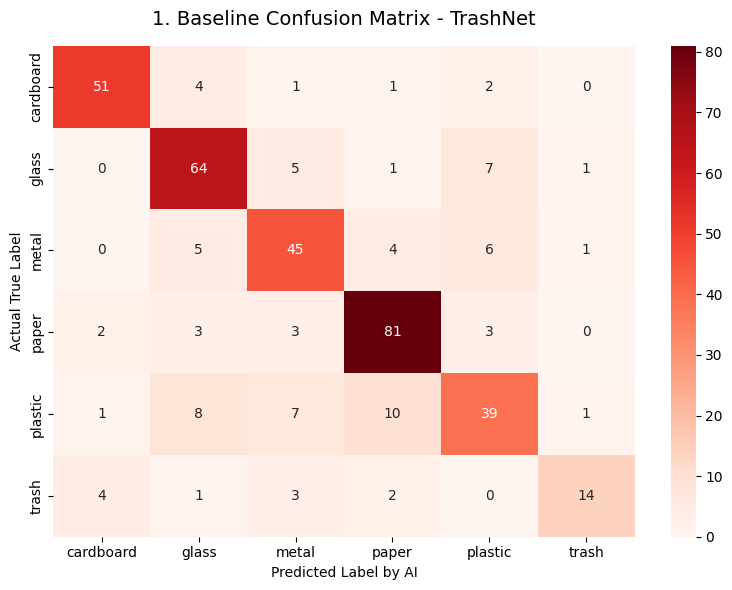

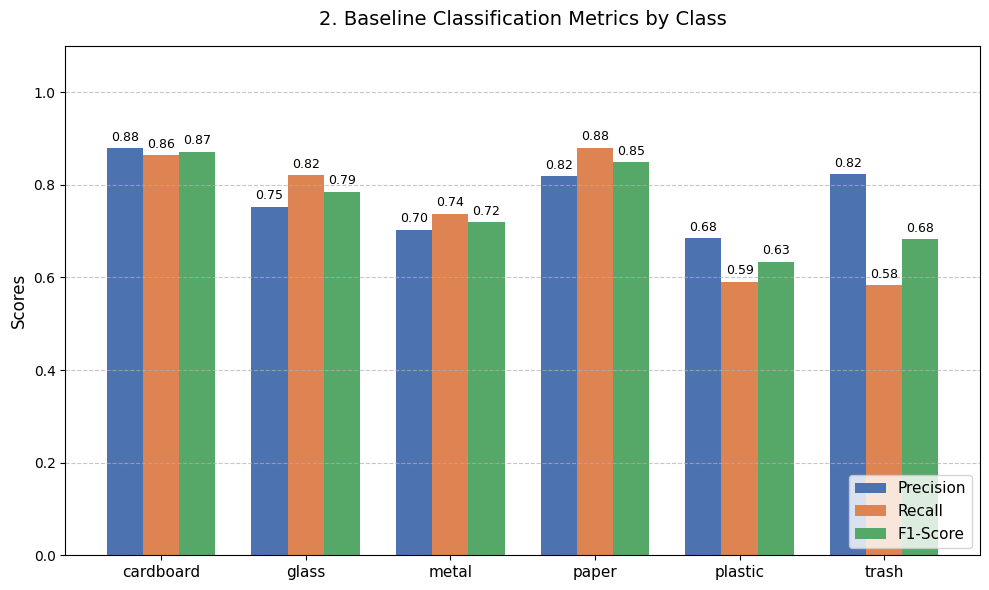

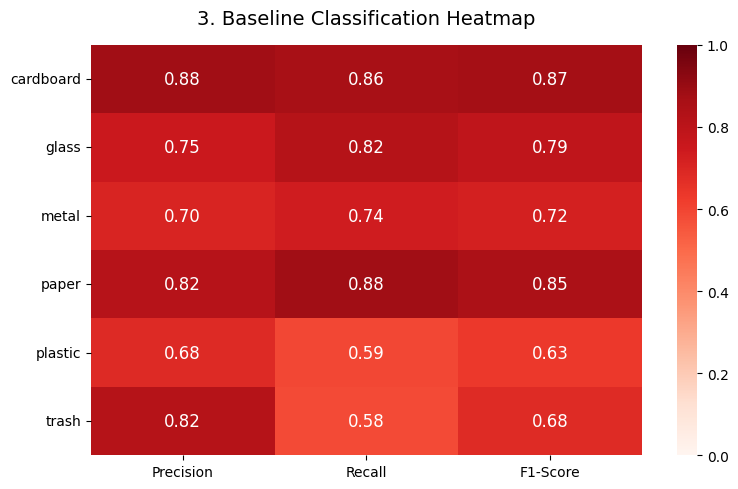

Valutazione completata! I grafici della Baseline sono stati salvati su disco.


In [17]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Impostiamo il modello CUSTOM in modalità valutazione
model_custom.eval()

all_preds = []
all_labels = []

print("Avvio della valutazione sul Test Set per la Baseline (TrashNet)...")

# 2. Iteriamo sui dati di test
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # forward pass usando il modello costruito da zero
        outputs = model_custom(inputs)
        _, preds = torch.max(outputs, 1)

        # salviamo le predizioni
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Recuperiamo i nomi delle classi
class_names = full_test_dataset.classes
print(f"\nClassi rilevate: {class_names}\n")

# --- TEXT REPORT ---
print("--- Classification Report (Baseline) ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Otteniamo i dati come dizionario per i grafici
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

precision = [report_dict[cls]['precision'] for cls in class_names]
recall = [report_dict[cls]['recall'] for cls in class_names]
f1_score = [report_dict[cls]['f1-score'] for cls in class_names]

# ==========================================
# PLOT 1: CONFUSION MATRIX (BASELINE)
# ==========================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names) # Usiamo il rosso per distinguerla dalla ResNet
plt.title('1. Baseline Confusion Matrix - TrashNet', fontsize=14, pad=15)
plt.ylabel('Actual True Label')
plt.xlabel('Predicted Label by AI')
plt.tight_layout()
plt.savefig('baseline_1_confusion_matrix.png', dpi=300)
plt.show()

# ==========================================
# PLOT 2: GROUPED BAR CHART (BASELINE METRICS)
# ==========================================
x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4C72B0')
rects2 = ax.bar(x, recall, width, label='Recall', color='#DD8452')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#55A868')

ax.set_ylabel('Scores', fontsize=12)
ax.set_title('2. Baseline Classification Metrics by Class', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.savefig('baseline_2_metrics_barchart.png', dpi=300)
plt.show()

# ==========================================
# PLOT 3: METRICS HEATMAP (BASELINE)
# ==========================================
data_metrics = np.array([precision, recall, f1_score]).T
df_metrics = pd.DataFrame(data_metrics, columns=['Precision', 'Recall', 'F1-Score'], index=class_names)

plt.figure(figsize=(8, 5))
sns.heatmap(df_metrics, annot=True, cmap='Reds', vmin=0, vmax=1, fmt='.2f', annot_kws={"size": 12}) # Usiamo il rosso anche qui
plt.title('3. Baseline Classification Heatmap', fontsize=14, pad=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('baseline_3_metrics_heatmap.png', dpi=300)
plt.show()

print("Valutazione completata! I grafici della Baseline sono stati salvati su disco.")

Grad-CAM initialized for Baseline Model. Picking 1 random test image per class (6 total)...


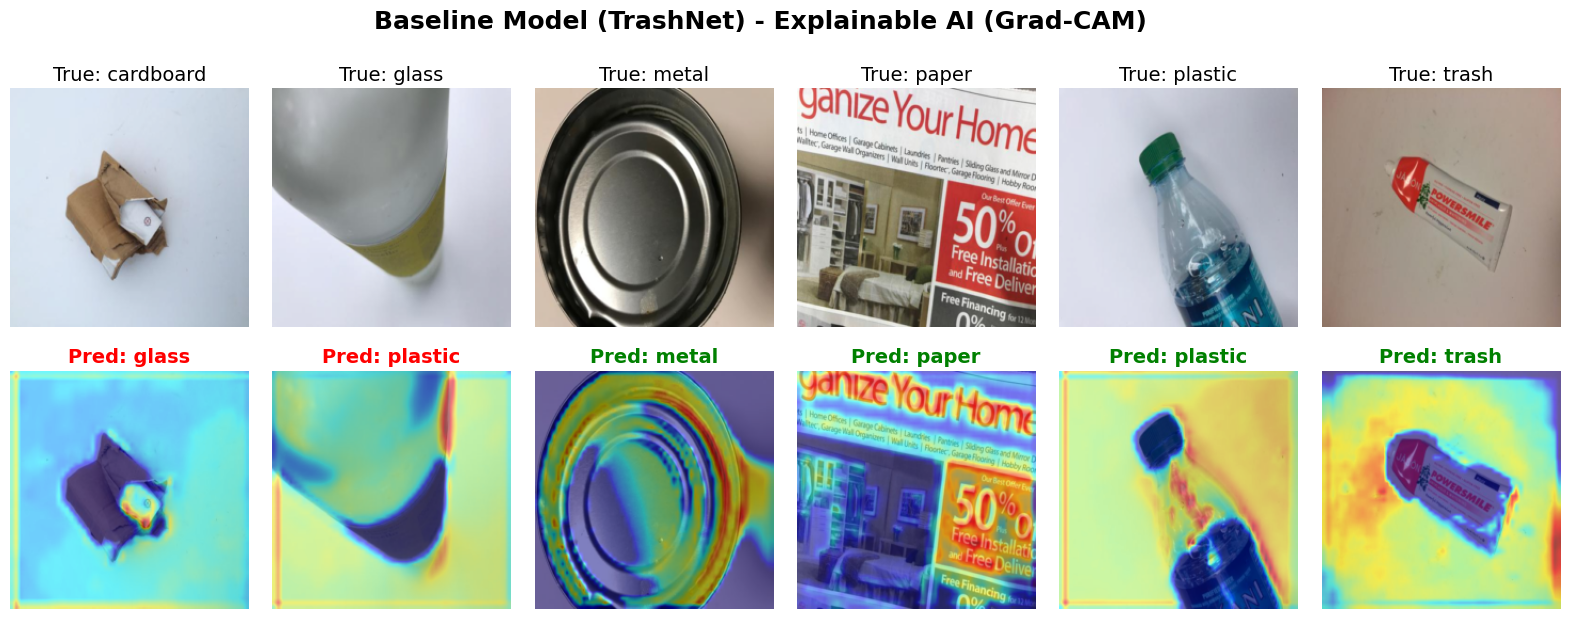

Heatmaps generated and saved successfully!


In [19]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Unfreeze the model parameters so Grad-CAM can backpropagate gradients
for param in model_custom.parameters():
    param.requires_grad = True

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Setup Grad-CAM for the Custom Baseline Model
# Our last convolutional layer is named 'conv3'
target_layers = [model_custom.conv3]
cam = GradCAM(model=model_custom, target_layers=target_layers)

print("Grad-CAM initialized for Baseline Model. Picking 1 random test image per class (6 total)...")

model_custom.eval()

# --- STRATIFIED RANDOMIZATION (1 image per class) ---
random_images = []
random_labels = []

# Iterate through each of the 6 classes to pick exactly one random image per class
for class_idx in range(len(class_names)):
    # Retrieve all indices in the test set belonging to the current class
    class_indices = [i for i, (_, label) in enumerate(test_data) if label == class_idx]
    # Pick exactly one random index for this class
    chosen_idx = random.choice(class_indices)
    
    img_tensor, label_idx = test_data[chosen_idx]
    random_images.append(img_tensor)
    random_labels.append(label_idx)

# Stack the selected images into a single batch tensor and move to device
inputs = torch.stack(random_images).to(device)
labels = torch.tensor(random_labels).to(device)
# ----------------------------------------------------

outputs = model_custom(inputs)
_, preds = torch.max(outputs, 1)

# Create a 2x6 grid for the 6 classes
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i in range(6): # Loop through all 6 selected images
    input_tensor = inputs[i].unsqueeze(0)
    true_label = class_names[labels[i].item()]
    pred_label = class_names[preds[i].item()]

    targets = [ClassifierOutputTarget(preds[i].item())]
    
    # Generate the heatmap
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    original_img = denormalize(inputs[i].cpu())
    visualization = show_cam_on_image(original_img, grayscale_cam, use_rgb=True)

    # Top Row: Original Image
    axes[0, i].imshow(original_img)
    axes[0, i].set_title(f"True: {true_label}", fontsize=14)
    axes[0, i].axis('off')

    # Bottom Row: Heatmap
    axes[1, i].imshow(visualization)
    color = 'green' if true_label == pred_label else 'red'
    axes[1, i].set_title(f"Pred: {pred_label}", color=color, fontsize=14, fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle("Baseline Model (TrashNet) - Explainable AI (Grad-CAM)", fontsize=18, fontweight='bold')

# Adjust spacing to avoid overlapping text
plt.subplots_adjust(hspace=0.1, top=0.88, wspace=0.1)
plt.savefig('baseline_4_gradcam.png', dpi=300)
plt.show()

print("Heatmaps generated and saved successfully!")